## Постановка задачи

Имеется выборка некоторой СВ $\xi$ в виде интервального статистического ряда (табл.).  
Требуется:  
а) построить гистограмму и график эмпирической функции распределения $F_n(x)$;  
б) вычислить выборочные: среднее, дисперсию, медиану, нижний и верхний квартили, коэффициент вариации, коэффициент асимметрии, эксцесс, коэффициент эксцесса;  
в) добавить искусственно к данным большую флуктуацию (порядка 1000)  
Как изменятся вычисленные параметры? Почему?  

## Генерация выборки

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

In [7]:
intervals = [(150,175), (175,200), (200,225), (225,250), (250,275)] # Интервалы
freq = np.array([160,340,345,135,20]) # Частоты
midpoints = np.array([(a+b)/2 for a,b in intervals]) # Середины интервалов
n = freq.sum() # Объем выборки

In [8]:
data = np.repeat(midpoints, freq) # Восстановление выборки (аппроксимация по средним)

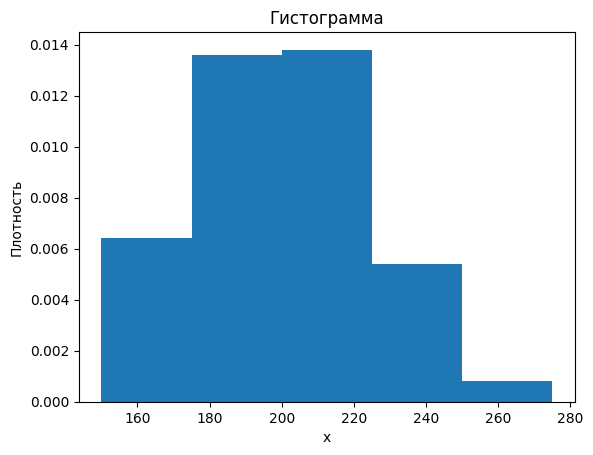

In [9]:
# Гистограмма

plt.figure()
plt.hist(data, bins=[150,175,200,225,250,275], density=True)
plt.title("Гистограмма")
plt.xlabel("x")
plt.ylabel("Плотность")
plt.show()

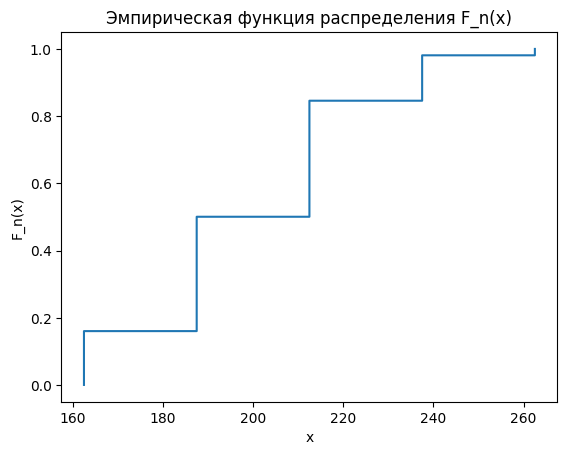

In [10]:
# Эмпирическая функция распределения

sorted_data = np.sort(data)
Fn = np.arange(1, n+1) / n

plt.figure()
plt.step(sorted_data, Fn)
plt.title("Эмпирическая функция распределения F_n(x)")
plt.xlabel("x")
plt.ylabel("F_n(x)")
plt.show()

## Характеристики

In [11]:
# Выборочные характеристики (Python slices)

n = len(data)
mean = sum(data) / n
variance = sum((x - mean) ** 2 for x in data) / (n - 1)
std = variance ** 0.5
data_sorted = sorted(data)
if n % 2 == 0:
    median = (data_sorted[n//2 - 1] + data_sorted[n//2]) / 2
else:
    median = data_sorted[n//2]
q1 = data_sorted[n // 4]
q3 = data_sorted[3 * n // 4]
cv = std / mean
skewness = sum(((x - mean) / std) ** 3 for x in data) / n
kurtosis = sum(((x - mean) / std) ** 4 for x in data) / n
excess_coef = kurtosis - 3

print("Среднее:", mean)
print("Дисперсия:", variance)
print("Медиана:", median)
print("Q1:", q1)
print("Q3:", q3)
print("Коэффициент вариации:", cv)
print("Асимметрия:", skewness)
print("Эксцесс:", kurtosis)
print("Коэффициент эксцесса:", excess_coef)


Среднее: 200.375
Дисперсия: 600.4598348348349
Медиана: 200.0
Q1: 187.5
Q3: 212.5
Коэффициент вариации: 0.12229211213663901
Асимметрия: 0.19704745935686713
Эксцесс: 2.4973326093309307
Коэффициент эксцесса: -0.5026673906690693


## Выброс

In [13]:
# Выборочные характеристики с выбросом 1000 (Python Slices)

data_outlier = list(data.copy())
data_outlier.append(1000)

n2 = len(data_outlier)
mean2 = sum(data_outlier) / n2
variance2 = sum((x - mean2) ** 2 for x in data_outlier) / (n2 - 1)
std2 = variance2 ** 0.5
data_sorted2 = sorted(data_outlier)
if n2 % 2 == 0:
    median2 = (data_sorted2[n2//2 - 1] + data_sorted2[n2//2]) / 2
else:
    median2 = data_sorted2[n2//2]
q1_2 = data_sorted2[n2 // 4]
q3_2 = data_sorted2[3 * n2 // 4]
cv2 = std2 / mean2
skewness2 = sum(((x - mean2) / std2) ** 3 for x in data_outlier) / n2
kurtosis2 = sum(((x - mean2) / std2) ** 4 for x in data_outlier) / n2

print("Новое среднее:", mean2)
print("Новая дисперсия:", variance2)
print("Новая медиана:", median2)
print("Новое Q1:", q1_2)
print("Новое Q3:", q3_2)
print("Новый коэффициент вариации:", cv2)
print("Новая асимметрия:", skewness2)
print("Новый эксцесс:", kurtosis2 + 3)
print("Новый коэффициент эксцесса:", kurtosis2)

Новое среднее: 201.17382617382617
Новая дисперсия: 1238.6207542457516
Новая медиана: 212.5
Новое Q1: 187.5
Новое Q3: 212.5
Новый коэффициент вариации: 0.17494345546908852
Новая асимметрия: 11.715435397769333
Новый эксцесс: 268.73589093470434
Новый коэффициент эксцесса: 265.73589093470434


## Наблюдения
**Среднее** - немного возросло  
**Дисперсия** - сильно возросла, поскольку она содержит квадраты отклонения, что является достаточно большой величиной  
**Коэффициент вариации** - резко возростает так как возрастает стандартное отклонение  
**Асимметрия** - появляется "тяжелый правый хвост"  
**Эксцесс** - резко возрастет т.к. оно становится "островершинным"  

## Вывод  
Дисперсия, асимметрия, эксцесс, среднее - *неустойчивые* оценки  
Медиана, квартили - *устойчивые* оценки